In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pytesseract

from pathlib import Path

print(cv2.data.haarcascades)

c:\Users\Pablo Perez\anaconda3\envs\DSRNArtificiales\Lib\site-packages\cv2\data\


[[ 128  216 1075  358]]


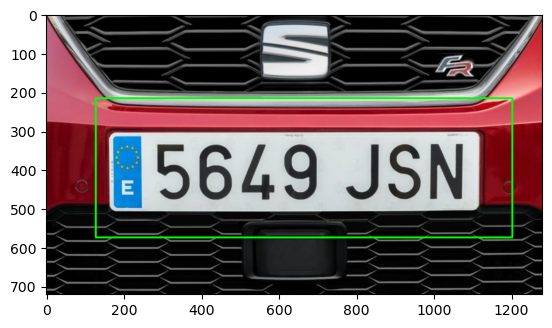

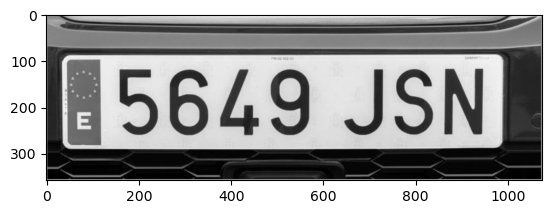

In [5]:
# Cargar
img = cv2.imread('Placas/placa2.jpg')
img = cv2.cvtColor( img, cv2.COLOR_BGR2RGB )
# Detectar con cascade
cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_russian_plate_number.xml')
plates = cascade.detectMultiScale(img, scaleFactor=1.3, minNeighbors=3, minSize=(30,30) )
print(plates)

for ( x, y, w, h ) in plates:
    cv2.rectangle( img, ( x, y ), ( x + w, y + h), ( 0, 255, 0 ), 3 )
    
plt.imshow( img, cmap='Accent' )
plt.show()

resizedImg = img[ y : y + h, x : x + w, : ]
resizedImg = cv2.cvtColor(resizedImg, cv2.COLOR_RGB2GRAY)
plt.imshow( resizedImg, cmap='gray' )
plt.show()

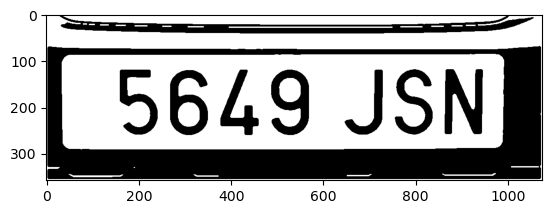

5649 JSN




In [6]:
ret, placaBin = cv2.threshold( resizedImg, 90, 18, cv2.THRESH_BINARY )
placaBin = cv2.medianBlur( placaBin, 5)
plt.imshow( placaBin, cmap='gray' )
plt.show()

textoBin = pytesseract.image_to_string( placaBin )
print( textoBin )

## Detección de Placa Mexicana para placa 3

Solo pude hacer la deteccion de esta placa, ya que las demas placas al ser mas pequeñas o mas grandes, se debería hacer otro tipo de procesamiento mas a fondo.

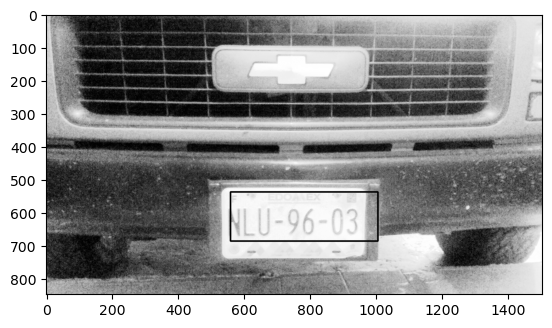

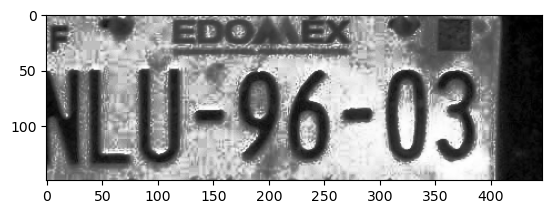

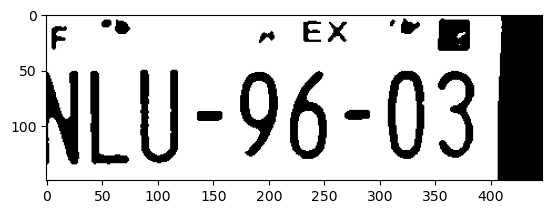

HLU-96-038



In [287]:
import cv2
import matplotlib.pyplot as plt
import pytesseract

img = cv2.imread('Placas/placa3.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = cv2.equalizeHist(gray)

cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_russian_plate_number.xml')
plates = cascade.detectMultiScale(gray, scaleFactor=1.001, minNeighbors=4 )

if plates.size >= 1:

    idx_mayor = np.argmax(plates[:, 2] * plates[:, 3])

    ( x, y, w, h ) = plates[idx_mayor]
    cv2.rectangle( gray, ( x, y ), ( x + w, y + h), ( 0, 255, 0 ), 3 )
    plt.imshow( gray, cmap='gray' )
    plt.show()

    resizedImg = img[ y : y + h, x : x + w, : ]
    resizedImg = cv2.cvtColor(resizedImg, cv2.COLOR_BGR2GRAY)
    resizedImg = cv2.equalizeHist(resizedImg)
    plt.imshow( resizedImg, cmap='gray' )
    plt.show()

    ret, placaBin2 = cv2.threshold( resizedImg, 60, 1, cv2.THRESH_BINARY  )
    placaBin2 = cv2.medianBlur( placaBin2, 3)

    plt.imshow( placaBin2, cmap='gray' )
    plt.show()

    textoBin2 = pytesseract.image_to_string( placaBin2 )
    print( textoBin2 )
